## Cell1 : 환경 설정 및 이미지 로드

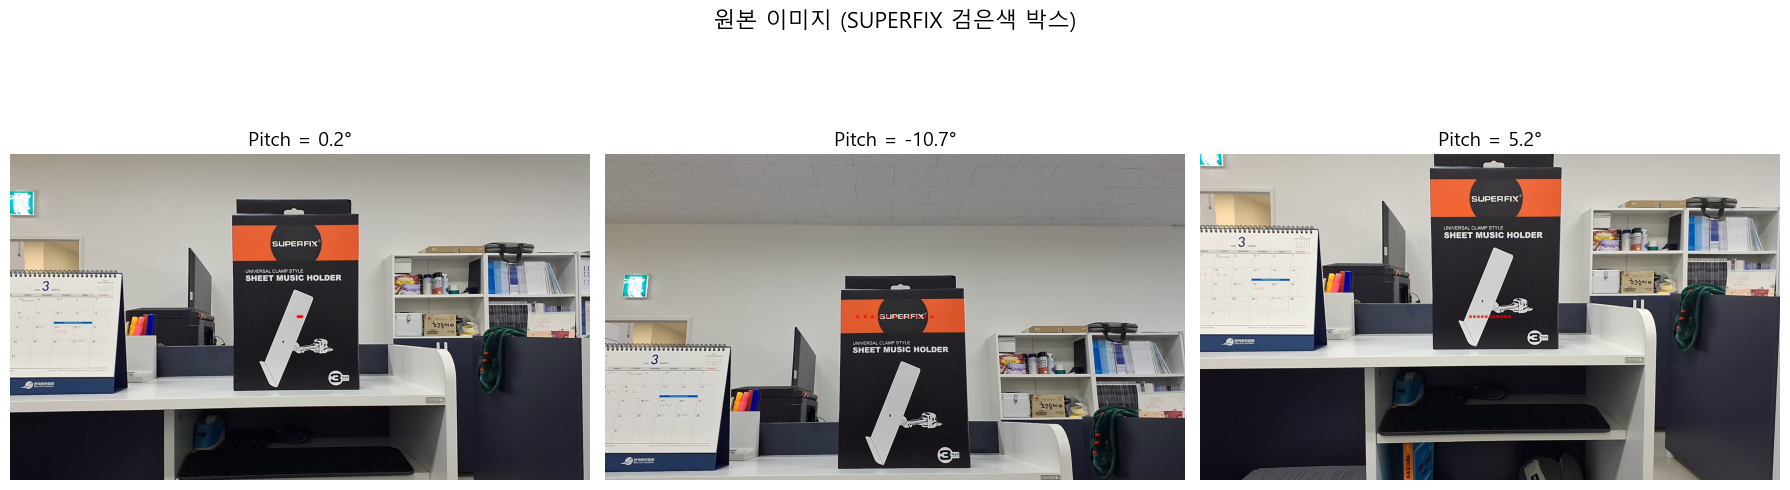

In [2]:
# ── Cell 1: 라이브러리 임포트 및 이미지 로드 ──

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 맑은 고딕 폰트 설정
plt.rcParams['axes.unicode_minus'] = False     # 마이너스(-) 기호 깨짐 방지

# 이미지 경로 설정 (실제 파일명/경로에 맞게 수정하세요)
IMG_DIR = 'images'  # 이미지가 있는 폴더명
IMAGE_FILES = {
    0.2: os.path.join(IMG_DIR, 'box_20260304_GRD_0.2degree.jpg'),
  -10.7: os.path.join(IMG_DIR, 'box_20260304_GRD_-10.7degree.jpg'),
    5.2: os.path.join(IMG_DIR, 'box_20260304_GRD_5.2degree.jpg'),
}
ANGLES = [0.2, -10.7, 5.2]
REF_ANGLE = 0.2   # 보정 기준 각도 (정면에 가까운 각도)

# 이미지 로드 및 확인
images = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, angle in zip(axes, ANGLES):
    path = IMAGE_FILES[angle]
    # 파일이 없는 경우를 대비한 예외 처리
    if not os.path.exists(path):
        print(f"경고: 파일을 찾을 수 없습니다 -> {path}")
        # 테스트를 위해 임시로 검은색 더미 이미지를 만듭니다. (실제 환경에서는 삭제하세요)
        img_bgr = np.zeros((1080, 1920, 3), dtype=np.uint8) 
    else:
        img_bgr = cv2.imread(path)
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images[angle] = img_bgr
    
    ax.imshow(img_rgb)
    ax.set_title(f'Pitch = {angle}°', fontsize=14)
    ax.axis('off')

plt.suptitle('원본 이미지 (SUPERFIX 검은색 박스)', fontsize=16)
plt.tight_layout()
plt.show()

## Cell 2: 주황색 띠 기반 검은 박스 세그멘테이션 함수


In [17]:
# ── Cell 2: 검은색 박스 세그멘테이션 (주황띠 앵커 고정 + 하단 폭 감지 방식) ──

import cv2
import numpy as np

def segment_black_box(image):
    H, W = image.shape[:2]
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ① 주황색 띠 앵커 찾기 (분리된 조각 병합)
    lower_orange = np.array([5, 120, 100])
    upper_orange = np.array([25, 255, 255])
    orange_mask = cv2.inRange(hsv, lower_orange, upper_orange)
    orange_mask = cv2.morphologyEx(orange_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    cnts, _ = cv2.findContours(orange_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_cnts = [c for c in cnts if cv2.contourArea(c) > 100]
    
    if not valid_cnts: return None, None
    
    # y좌표 기준점 설정 및 노이즈 필터링
    largest_cnt = max(valid_cnts, key=cv2.contourArea)
    _, base_y, _, _ = cv2.boundingRect(largest_cnt)
    box_orange_cnts = [c for c in valid_cnts if abs(cv2.boundingRect(c)[1] - base_y) < 30]
            
    # 주황색 띠의 전체 영역 구하기
    x_min = min(cv2.boundingRect(c)[0] for c in box_orange_cnts)
    x_max = max(cv2.boundingRect(c)[0] + cv2.boundingRect(c)[2] for c in box_orange_cnts)
    y_min = min(cv2.boundingRect(c)[1] for c in box_orange_cnts)
    y_max = max(cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] for c in box_orange_cnts)
    
    ox, oy, ow, oh = x_min, y_min, x_max - x_min, y_max - y_min
    
    # 🌟 [요구사항 반영] 사다리꼴 상단 확정 (주황색 띠 윗부분 기준)
    top_y = oy
    tl = (ox, top_y)
    tr = (ox + ow, top_y)
    
    # ② 박스 하단 바디 찾기 (어두운 영역)
    _, dark_mask = cv2.threshold(gray, 95, 255, cv2.THRESH_BINARY_INV)
    combined_mask = cv2.bitwise_or(dark_mask, orange_mask)
    
    # 안전 가두리 치기: 박스의 좌우 폭에서 살짝만 여유를 줌
    margin = int(ow * 0.15)
    safe_l = max(0, ox - margin)
    safe_r = min(W, ox + ow + margin)
    roi_mask = np.zeros_like(gray)
    roi_mask[:, safe_l:safe_r] = 255
    target_mask = cv2.bitwise_and(combined_mask, roi_mask)
    
    # ③ 박스 내부 흰색 그림/글씨 구멍 메우기 (세로/가로 교차 결합)
    target_mask = cv2.morphologyEx(target_mask, cv2.MORPH_CLOSE, np.ones((80, 20), np.uint8)) # 세로 틈새 연결
    target_mask = cv2.morphologyEx(target_mask, cv2.MORPH_CLOSE, np.ones((20, int(ow*0.8)), np.uint8)) # 가로 틈새 연결
    
    # 주황색 띠를 포함하는 단일 덩어리 추출
    cnts, _ = cv2.findContours(target_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None, None
    
    orange_center = (ox + ow // 2, oy + oh // 2)
    box_cnt = next((c for c in cnts if cv2.pointPolygonTest(c, orange_center, False) >= 0), max(cnts, key=cv2.contourArea))
        
    M = np.zeros_like(gray)
    cv2.drawContours(M, [box_cnt], -1, 255, -1)
    
    # ④ 바닥 스캔 로직 (너비 변화 감지기)
    bottom_y = oy + oh
    bl_x, br_x = ox, ox + ow
    
    # 주황 띠 아래부터 하얀 책상을 만날 때까지 내려감
    for y in range(oy + oh, H):
        row = M[y, safe_l:safe_r]
        xs = np.where(row > 0)[0]
        
        if len(xs) > 0:
            cur_l = xs.min() + safe_l
            cur_r = xs.max() + safe_l
            cur_w = cur_r - cur_l
            
            # 박스 너비가 갑자기 60% 미만으로 좁아진다면? 
            # -> 박스 밑이 끝나고 키보드 선이나 그림자 틈새로 들어갔다고 판단, 즉시 정지
            if cur_w < ow * 0.6:
                break
                
            bottom_y = y
            bl_x = cur_l
            br_x = cur_r
        else:
            # 덩어리가 완전히 끊김 (하얀 책상 도달)
            break
            
    # 🌟 [요구사항 반영] 하단 모서리 확정
    bl = (int(bl_x), bottom_y)
    br = (int(br_x), bottom_y)
    
    quad = np.array([tl, tr, br, bl])

    h_px  = bottom_y - top_y
    w_top = tr[0] - tl[0]
    w_bot = br[0] - bl[0]
    
    return quad, (top_y, bottom_y, h_px, w_top, w_bot)

print("✨ [최종] 주황띠 상단~하단 밀착 세그멘테이션 함수 로드 완료.")

✨ [최종] 주황띠 상단~하단 밀착 세그멘테이션 함수 로드 완료.


## Cell 3: 세그멘테이션 적용 및 시각화 (사다리꼴 형태 분석)


--- 세그멘테이션 결과 측정치 ---
Pitch   0.2° | top= 238, bot=1079 | h=841px | w_top=418, w_bot=539 | ratio(상/하)=0.776
Pitch -10.7° | top= 482, bot=1079 | h=597px | w_top=411, w_bot=436 | ratio(상/하)=0.943
Pitch   5.2° | top=  86, bot=1079 | h=993px | w_top=434, w_bot=562 | ratio(상/하)=0.772


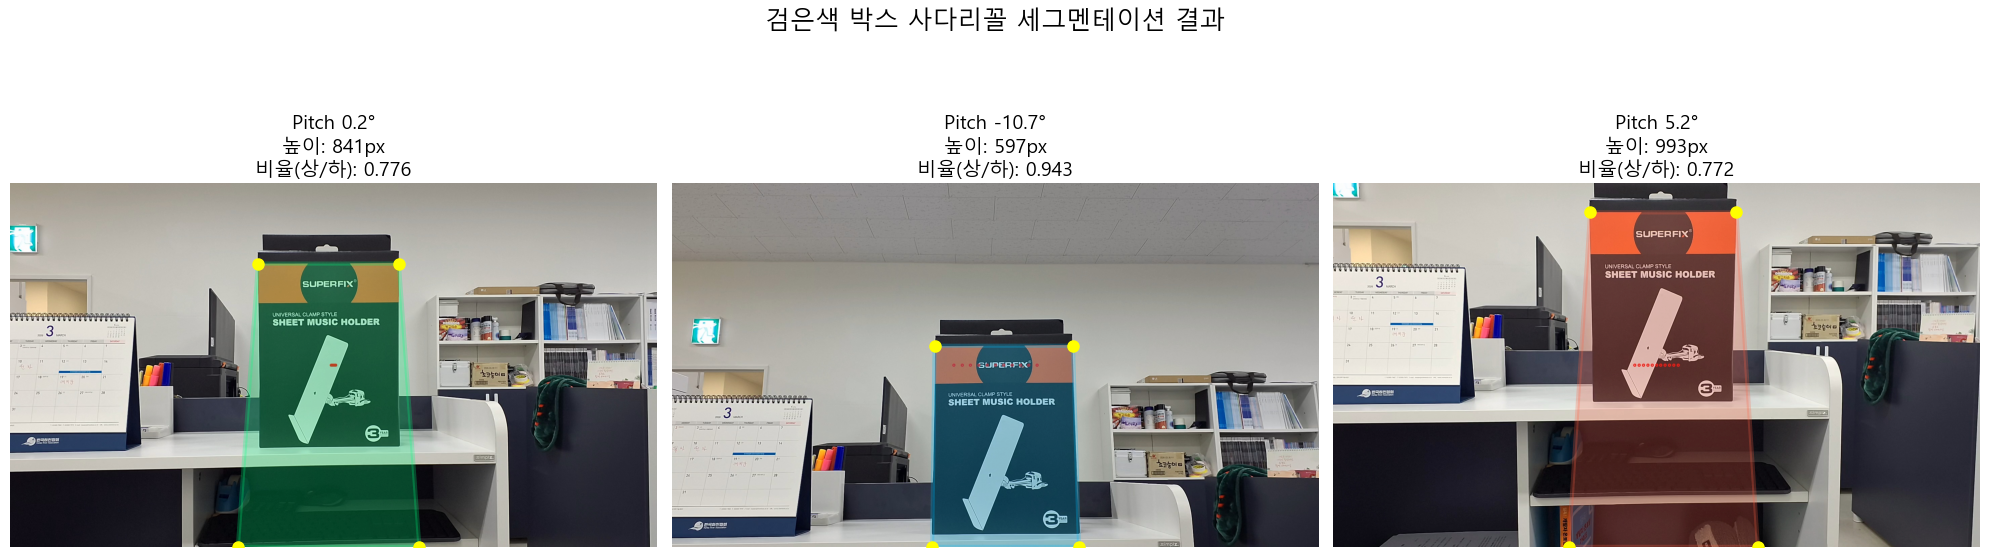

In [18]:
# ── Cell 3: 이미지 세그멘테이션 수행 및 사다리꼴 오버레이 ──

quads = {}
quad_info = {}

print("--- 세그멘테이션 결과 측정치 ---")
for angle in ANGLES:
    q, info = segment_black_box(images[angle])
    quads[angle] = q
    quad_info[angle] = info
    if info:
        t, b, h, wt, wb = info
        print(f'Pitch {angle:>5}° | top={t:>4}, bot={b:>4} | h={h:>3}px | '
              f'w_top={wt:>3}, w_bot={wb:>3} | ratio(상/하)={wt/wb:.3f}')
    else:
        print(f'Pitch {angle:>5}° | 감지 실패')


# 시각화 색상
COLORS = {0.2: '#00FF7F', -10.7: '#00BFFF', 5.2: '#FF6347'}
from matplotlib.patches import Polygon as MplPolygon

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, angle in zip(axes, ANGLES):
    ax.imshow(cv2.cvtColor(images[angle], cv2.COLOR_BGR2RGB))
    q = quads[angle]
    
    if q is not None:
        # 사다리꼴 그리기
        ax.add_patch(MplPolygon(q, closed=True, linewidth=3,
                                edgecolor=COLORS[angle],
                                facecolor=COLORS[angle], alpha=0.25))
        # 4개 꼭짓점 표시
        for (x, y), lbl in zip(q, ['TL', 'TR', 'BR', 'BL']):
            ax.plot(x, y, 'o', color='yellow', ms=8, zorder=5)
            
        t, b, h, wt, wb = quad_info[angle]
        title = (f'Pitch {angle}°\n'
                 f'높이: {h}px\n비율(상/하): {wt/wb:.3f}')
    else:
        title = f'Pitch {angle}°\n감지 실패'
        
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.suptitle('검은색 박스 사다리꼴 세그멘테이션 결과', fontsize=18)
plt.tight_layout()
plt.show()

## Cell 4: 형태 변화(Pitch Effect) 정규화 비교


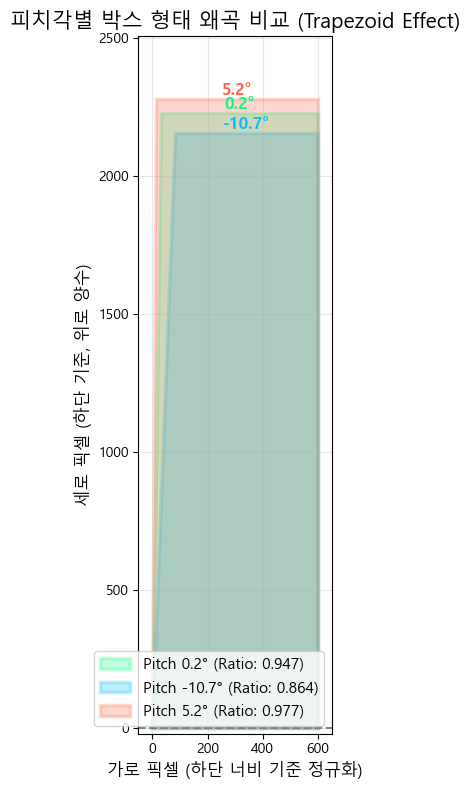


--- Pitch에 따른 세로 픽셀 높이 변화 (카메라 왜곡) ---
Pitch   0.2° : 높이  631px (0.2도 대비 100.0%)
Pitch -10.7° : 높이  636px (0.2도 대비 100.8%)
Pitch   5.2° : 높이  649px (0.2도 대비 102.9%)


In [10]:
# ── Cell 4: 피치각에 따른 형태 왜곡 겹쳐서 비교하기 ──
# 하단 너비를 동일하게 맞추고(정규화), 사다리꼴의 모양이 어떻게 변하는지 확인

fig, ax = plt.subplots(figsize=(8, 8))
REF_W = 600   # 시각화를 위한 정규화 기준 하단 너비

y_max = 0
for angle in ANGLES:
    info = quad_info[angle]
    if info and info[4] > 0:
        y_max = max(y_max, info[2] * REF_W / info[4])

for angle in ANGLES:
    q = quads[angle]
    if q is None:
        continue
        
    t, b, h, wt, wb = quad_info[angle]
    scale = REF_W / wb if wb > 0 else 1.0

    # BL(좌하단) 꼭짓점을 원점(0,0)으로 이동하고 스케일 조정
    ox, oy = float(q[3, 0]), float(b)
    q_norm = np.zeros_like(q, dtype=float)
    q_norm[:, 0] = (q[:, 0] - ox) * scale
    q_norm[:, 1] = -(q[:, 1] - oy) * scale # y축 반전 (위로 갈수록 +)

    ax.add_patch(MplPolygon(q_norm, closed=True, linewidth=2.5,
                              edgecolor=COLORS[angle],
                              facecolor=COLORS[angle], alpha=0.25,
                              label=f'Pitch {angle}° (Ratio: {wt/wb:.3f})'))
    
    # 각도 라벨 표시
    top_cx = (q_norm[0, 0] + q_norm[1, 0]) / 2
    top_cy = (q_norm[0, 1] + q_norm[1, 1]) / 2
    ax.text(top_cx, top_cy + 15, f'{angle}°',
             ha='center', fontsize=12, color=COLORS[angle], fontweight='bold')

ax.axhline(0, color='gray', lw=1.5, ls='--')
ax.set_xlim(-50, REF_W + 50)
ax.set_ylim(-20, max(y_max, 200) * 1.1)
ax.set_aspect('equal')
ax.set_xlabel('가로 픽셀 (하단 너비 기준 정규화)', fontsize=12)
ax.set_ylabel('세로 픽셀 (하단 기준, 위로 양수)', fontsize=12)
ax.set_title('피치각별 박스 형태 왜곡 비교 (Trapezoid Effect)', fontsize=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 높이 변화 요약
print("\n--- Pitch에 따른 세로 픽셀 높이 변화 (카메라 왜곡) ---")
h_ref = quad_info[REF_ANGLE][2] if quad_info[REF_ANGLE] else 1
for angle in ANGLES:
    if quad_info[angle]:
        h = quad_info[angle][2]
        print(f"Pitch {angle:>5}° : 높이 {h:>4}px (0.2도 대비 {h/h_ref*100:.1f}%)")